# RadioML 2016.10A — Dataset Preparation

Prepares the BPSK IQ dataset used by the SoftGAN experiment.


## 1. Setup

Import the required libraries and define the experiment settings.


In [1]:
# 1) Imports, reproducibility, and configuration
!pip install -q kagglehub

import os
import json
import pickle
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

MODULATION = "BPSK"

# Recommended first experiment:
DATA_MODE = "single_snr"   # "single_snr" or "all_snr"
TARGET_SNR = 18            # Used only when DATA_MODE == "single_snr"

TRAIN_FRAC = 0.80
VAL_FRAC = 0.10
TEST_FRAC = 0.10

assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-12

print("Configuration:")
print("  Modulation :", MODULATION)
print("  Data mode  :", DATA_MODE)
print("  Target SNR :", TARGET_SNR if DATA_MODE == "single_snr" else "all")
print("  Seed       :", SEED)

Configuration:
  Modulation : BPSK
  Data mode  : single_snr
  Target SNR : 18
  Seed       : 42


## 2. Load RadioML

Download RadioML 2016.10A and load the IQ dataset.


In [2]:
# 2) Download and load RadioML 2016.10A
download_path = kagglehub.dataset_download("nolasthitnotomorrow/radioml2016-deepsigcom")
print("Downloaded to:", download_path)

dataset_path = None
for root, _, files in os.walk(download_path):
    for name in files:
        if name == "RML2016.10a_dict.pkl":
            dataset_path = os.path.join(root, name)
            break
    if dataset_path is not None:
        break

if dataset_path is None:
    raise FileNotFoundError("RML2016.10a_dict.pkl was not found.")

with open(dataset_path, "rb") as f:
    dataset = pickle.load(f, encoding="latin1")

print("Dataset type:", type(dataset))
print("Number of (modulation, SNR) groups:", len(dataset))
print("Dataset file:", dataset_path)

100%|██████████| 279M/279M [00:03<00:00, 89.4MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/nolasthitnotomorrow/radioml2016-deepsigcom/versions/1
Dataset type: <class 'dict'>
Number of (modulation, SNR) groups: 220
Dataset file: /root/.cache/kagglehub/datasets/nolasthitnotomorrow/radioml2016-deepsigcom/versions/1/RML2016.10a_dict.pkl


## 3. Check Dataset Structure

Inspect the available modulations, SNRs, and IQ sample shape.


In [3]:
# 3) Inspect and validate dataset structure
modulations = sorted({key[0] for key in dataset.keys()})
snrs = sorted({int(key[1]) for key in dataset.keys()})

print("Modulations:", modulations)
print("SNR values :", snrs)

if MODULATION not in modulations:
    raise ValueError(f"{MODULATION} is not present in the dataset.")

if DATA_MODE == "single_snr" and TARGET_SNR not in snrs:
    raise ValueError(f"SNR {TARGET_SNR} dB is not present in the dataset.")

example_snr = TARGET_SNR if TARGET_SNR in snrs else snrs[-1]
example_group = np.asarray(dataset[(MODULATION, example_snr)])

print(f"\n{MODULATION} at {example_snr} dB shape:", example_group.shape)
print("One IQ sample shape:", example_group[0].shape)
print("dtype:", example_group.dtype)

assert example_group.ndim == 3
assert example_group.shape[1] == 2, "Expected IQ channels on axis 1."
assert example_group.shape[2] == 128, "Expected sequence length 128."
assert np.isfinite(example_group).all(), "Dataset contains NaN or Inf."

Modulations: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR values : [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

BPSK at 18 dB shape: (1000, 2, 128)
One IQ sample shape: (2, 128)
dtype: float32


## 4. Visual Check

Plot BPSK samples at several SNR values for a quick sanity check.


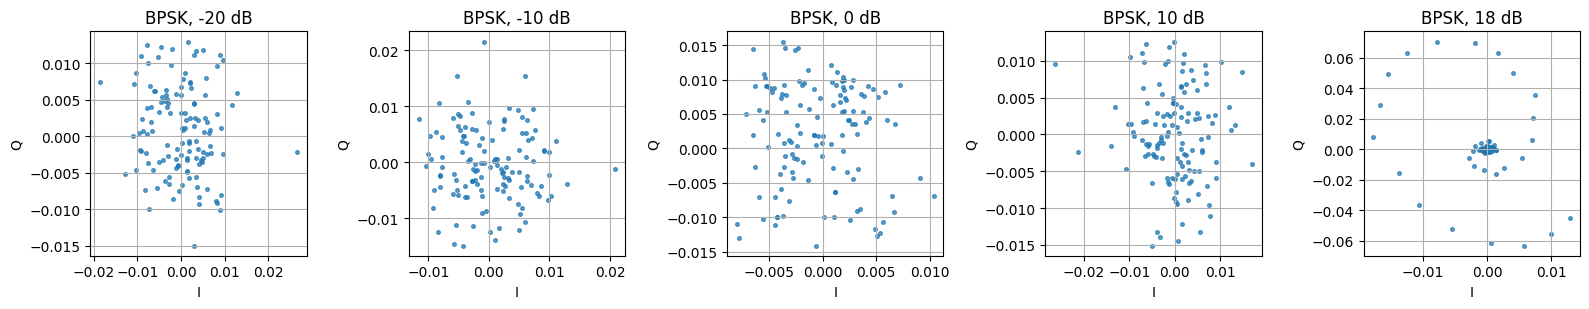

These SNR-dependent distributions are intentionally NOT mixed in the default diagnostic experiment.


In [4]:
# 4) Visual sanity check: BPSK changes strongly with SNR
snr_examples = [s for s in [-20, -10, 0, 10, 18] if s in snrs]

fig, axes = plt.subplots(1, len(snr_examples), figsize=(3.2 * len(snr_examples), 3.2))
if len(snr_examples) == 1:
    axes = [axes]

for ax, snr in zip(axes, snr_examples):
    x = np.asarray(dataset[(MODULATION, snr)])[0]
    ax.scatter(x[0], x[1], s=7, alpha=0.7)
    ax.set_title(f"{MODULATION}, {snr} dB")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.grid(True)

plt.tight_layout()
plt.show()

print(
    "These SNR-dependent distributions are intentionally NOT mixed in the "
    "default diagnostic experiment."
)

## 5. Select BPSK Samples

Build the dataset for either one SNR or all available SNR values.


In [5]:
# 5) Build the selected dataset
if DATA_MODE == "single_snr":
    X = np.asarray(dataset[(MODULATION, TARGET_SNR)], dtype=np.float32)
    y_snr = np.full(len(X), TARGET_SNR, dtype=np.int16)
else:
    blocks = []
    labels = []
    for snr in snrs:
        block = np.asarray(dataset[(MODULATION, snr)], dtype=np.float32)
        blocks.append(block)
        labels.append(np.full(len(block), snr, dtype=np.int16))
    X = np.concatenate(blocks, axis=0)
    y_snr = np.concatenate(labels, axis=0)

print("Selected IQ shape :", X.shape)
print("SNR label shape   :", y_snr.shape)
print("Raw min/max       :", float(X.min()), float(X.max()))
print("Raw mean/std      :", float(X.mean()), float(X.std()))

assert X.ndim == 3 and X.shape[1:] == (2, 128)
assert len(X) == len(y_snr)
assert np.isfinite(X).all()

Selected IQ shape : (1000, 2, 128)
SNR label shape   : (1000,)
Raw min/max       : -0.06313645094633102 0.1642291247844696
Raw mean/std      : 9.882131962513085e-06 0.0059748548083007336


## 6. Split the Dataset

Create the 80/10/10 train, validation, and test partitions.


In [6]:
# 6) Create 80/10/10 split
# For all-SNR data, stratify by SNR.
# For one-SNR data, stratification is unnecessary because every label is identical.

stratify_first = y_snr if DATA_MODE == "all_snr" else None

X_train, X_temp, snr_train, snr_temp = train_test_split(
    X,
    y_snr,
    test_size=(VAL_FRAC + TEST_FRAC),
    random_state=SEED,
    shuffle=True,
    stratify=stratify_first
)

relative_test_frac = TEST_FRAC / (VAL_FRAC + TEST_FRAC)
stratify_second = snr_temp if DATA_MODE == "all_snr" else None

X_val, X_test, snr_val, snr_test = train_test_split(
    X_temp,
    snr_temp,
    test_size=relative_test_frac,
    random_state=SEED,
    shuffle=True,
    stratify=stratify_second
)

print("Train      :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)

assert len(X_train) + len(X_val) + len(X_test) == len(X)

Train      : (800, 2, 128)
Validation : (100, 2, 128)
Test       : (100, 2, 128)


## 7. Verify the Split

Check the SNR distribution in each partition.


In [7]:
# 7) Verify SNR counts after splitting
def print_snr_counts(name, labels):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name}")
    for s, c in zip(unique, counts):
        print(f"  {int(s):>3} dB : {int(c)}")

print_snr_counts("Train SNR counts", snr_train)
print_snr_counts("Validation SNR counts", snr_val)
print_snr_counts("Test SNR counts", snr_test)


Train SNR counts
   18 dB : 800

Validation SNR counts
   18 dB : 100

Test SNR counts
   18 dB : 100


## 8. Normalization Statistics

Compute I/Q normalization statistics using only the training set.


In [8]:
# 8) Compute normalization statistics from TRAINING DATA ONLY
# We compute one mean/std for I and one for Q.
# Shape is kept as (1, 2, 1) for easy broadcasting over (N, 2, 128).

train_mean = X_train.mean(axis=(0, 2), keepdims=True).astype(np.float32)
train_std = X_train.std(axis=(0, 2), keepdims=True).astype(np.float32)

EPS = 1e-8
train_std = np.maximum(train_std, EPS)

print("Training I/Q mean:", train_mean.reshape(-1))
print("Training I/Q std :", train_std.reshape(-1))

# Diagnostic only — do not overwrite the raw arrays.
X_train_z = (X_train - train_mean) / train_std
X_val_z = (X_val - train_mean) / train_std
X_test_z = (X_test - train_mean) / train_std

print("\nStandardized train mean:", X_train_z.mean(axis=(0, 2)))
print("Standardized train std :", X_train_z.std(axis=(0, 2)))
print("Standardized train range:", float(X_train_z.min()), float(X_train_z.max()))

Training I/Q mean: [ 1.5961787e-05 -1.6884846e-05]
Training I/Q std : [0.00529537 0.00661516]

Standardized train mean: [-6.7800285e-09  1.7107231e-09]
Standardized train std : [1.        0.9999998]
Standardized train range: -9.541658401489258 24.828739166259766


## 9. Final Checks

Verify data type, dimensions, and numerical validity before saving.


In [9]:
# 9) Sanity checks before saving
for name, arr in [("train", X_train), ("val", X_val), ("test", X_test)]:
    assert arr.dtype == np.float32
    assert arr.ndim == 3 and arr.shape[1:] == (2, 128)
    assert np.isfinite(arr).all()
    print(f"{name:>5}: OK | shape={arr.shape} | min={arr.min():.6f} | max={arr.max():.6f}")

print("\nDataset preparation checks passed.")

train: OK | shape=(800, 2, 128) | min=-0.063136 | max=0.164229
  val: OK | shape=(100, 2, 128) | min=-0.019347 | max=0.016650
 test: OK | shape=(100, 2, 128) | min=-0.016268 | max=0.018627

Dataset preparation checks passed.


## 10. Save the Dataset

Save the prepared IQ arrays, SNR labels, and normalization metadata to Drive.


In [10]:
# 10) Save processed dataset and metadata to Google Drive
from google.colab import drive
drive.mount("/content/drive")

if DATA_MODE == "single_snr":
    experiment_name = f"{MODULATION}_snr{TARGET_SNR}"
else:
    experiment_name = f"{MODULATION}_all_snr"

output_dir = Path("/content/drive/MyDrive/GenTWIN_Project/processed") / experiment_name
output_dir.mkdir(parents=True, exist_ok=True)

np.save(output_dir / "X_train.npy", X_train)
np.save(output_dir / "X_val.npy", X_val)
np.save(output_dir / "X_test.npy", X_test)

np.save(output_dir / "snr_train.npy", snr_train)
np.save(output_dir / "snr_val.npy", snr_val)
np.save(output_dir / "snr_test.npy", snr_test)

np.save(output_dir / "train_mean.npy", train_mean)
np.save(output_dir / "train_std.npy", train_std)

metadata = {
    "dataset": "RadioML2016.10A",
    "modulation": MODULATION,
    "data_mode": DATA_MODE,
    "target_snr_db": int(TARGET_SNR) if DATA_MODE == "single_snr" else None,
    "sequence_shape": [2, 128],
    "seed": SEED,
    "split": {
        "train": TRAIN_FRAC,
        "validation": VAL_FRAC,
        "test": TEST_FRAC,
    },
    "normalization": {
        "type": "per-IQ-channel z-score",
        "fit_on": "training set only",
        "stored_but_not_applied_to_saved_raw_IQ": True,
    },
}

with open(output_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved to:", output_dir)
print("\nFiles:")
for p in sorted(output_dir.iterdir()):
    print(" ", p.name)

Mounted at /content/drive
Saved to: /content/drive/MyDrive/GenTWIN_Project/processed/BPSK_snr18

Files:
  X_test.npy
  X_train.npy
  X_val.npy
  metadata.json
  snr_test.npy
  snr_train.npy
  snr_val.npy
  train_mean.npy
  train_std.npy


## Next Step

Use the saved dataset and normalization statistics in the SoftGAN notebook.
